In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
from astropy.coordinates import SkyCoord
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib.colors import Normalize
from astropy.visualization import ZScaleInterval
from functools import partial

In [2]:
plt.rcParams.update({'font.size': 12})

In [3]:
def convert_to_seconds(l):
    mjd, seconds = l.split('_')
    mjd, seconds = int(mjd), int(seconds)
    return mjd * 86400 + seconds

In [4]:
def get_mjd(l):
    return int(l.split('_')[0])

In [5]:
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/all_xband_info.csv')
info

,source,epoch,time,ra,dec,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq
0,HIP62637,AGBT23B_999_14,60291_31980,192.5380,19.8676,300.540925,82.733377,96.254146,86.314790,1.660433e+08,1.202716e+15,3.237142e+08,1.860099e+15,1.442647e+08,9.590752e+14,3.834180e+07,7.402785e+13
1,HIP38468,AGBT20B_999_54,59214_38477,118.1838,12.0399,208.821296,18.974616,117.121857,145.947125,1.058735e+08,5.479899e+14,2.602043e+08,1.212893e+15,9.089486e+07,4.472811e+14,2.322709e+07,3.181333e+13
2,HIP116538,AGBT20B_999_49,59203_03185,354.3079,57.9490,113.193170,-3.512770,23.443145,113.147054,1.279805e+08,7.541369e+14,2.869724e+08,1.465254e+15,1.107629e+08,6.130784e+14,2.865754e+07,4.469731e+13
3,HIP96264,AGBT20B_999_49,59203_36476,293.5826,71.6109,103.349354,22.362166,25.866928,102.328982,1.403981e+08,8.868837e+14,3.001235e+08,1.599971e+15,1.218205e+08,7.177445e+14,3.177227e+07,5.320469e+13
4,HIP53862,AGBT20A_999_44,59023_07533,165.2817,-5.7016,259.734245,47.703048,131.467876,96.888255,1.479999e+08,9.745009e+14,3.075883e+08,1.679683e+15,1.285353e+08,7.858121e+14,3.370077e+07,5.890246e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,HIP6529,AGBT20B_996_01,59225_75932,20.9600,25.9246,131.988102,-36.376712,53.241482,122.589484,1.195448e+08,6.710386e+14,2.772991e+08,1.370729e+15,1.032019e+08,5.466822e+14,2.656755e+07,3.945346e+13
4995,HIP5701,AGBT20B_996_01,59225_76780,18.3398,25.4659,129.141570,-37.141396,51.810902,120.211314,1.214849e+08,6.896553e+14,2.795800e+08,1.392673e+15,1.049437e+08,5.616120e+14,2.704631e+07,4.062254e+13
4996,HIP5777,AGBT20B_996_01,59225_78072,18.5185,25.8356,129.291960,-36.756451,51.679375,120.488749,1.212525e+08,6.874098e+14,2.793086e+08,1.390051e+15,1.047351e+08,5.598128e+14,2.698890e+07,4.048135e+13
4997,HIP5965,AGBT20B_996_01,59225_77421,19.1727,24.5039,130.227874,-38.009838,53.018922,120.587397,1.211702e+08,6.866161e+14,2.792124e+08,1.389122e+15,1.046613e+08,5.591768e+14,2.696859e+07,4.043146e+13


# **I. Theta/Phi Distribution by Epoch**

In [6]:
info_pre22B = info[info['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9)]
thetas_pre22B = [math.cos(math.radians(theta)) for theta in info_pre22B['theta']]
phis_pre22B = [math.cos(math.radians(phi)) for phi in info_pre22B['phi']]

info_post22B = info[info['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9)]
thetas_post22B = [math.cos(math.radians(theta)) for theta in info_post22B['theta']]
phis_post22B = [math.cos(math.radians(phi)) for phi in info_post22B['phi']]

Text(0.5, 1.0, 'Phi Distributions')

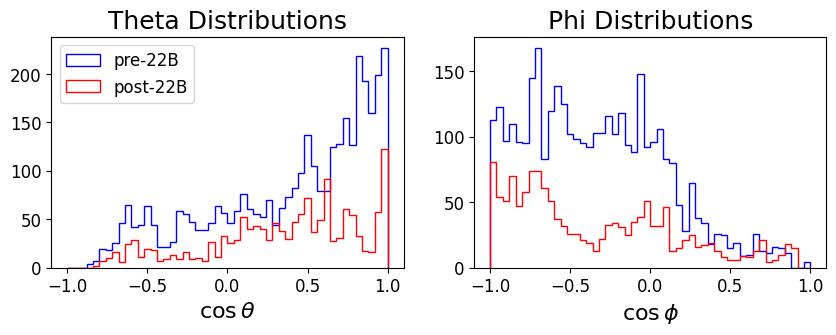

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(10,3))

axs[0].hist(thetas_pre22B, histtype='step', bins=np.linspace(-1, 1, 51), color='b', label='pre-22B')
axs[0].hist(thetas_post22B, histtype='step', bins=np.linspace(-1, 1, 51), color='r', label='post-22B')
axs[0].set_xlabel(r'$\cos{\theta}$', fontsize=16)
axs[0].set_title('Theta Distributions', fontsize=18)
axs[0].legend()

axs[1].hist(phis_pre22B, histtype='step', bins=np.linspace(-1, 1, 51), color='b')
axs[1].hist(phis_post22B, histtype='step', bins=np.linspace(-1, 1, 51), color='r')
axs[1].set_xlabel(r'$\cos{\phi}$', fontsize=16)
axs[1].set_title('Phi Distributions', fontsize=18)

## Distributions by bank

Text(0.5, 0, '$\\cos{\\phi}$')

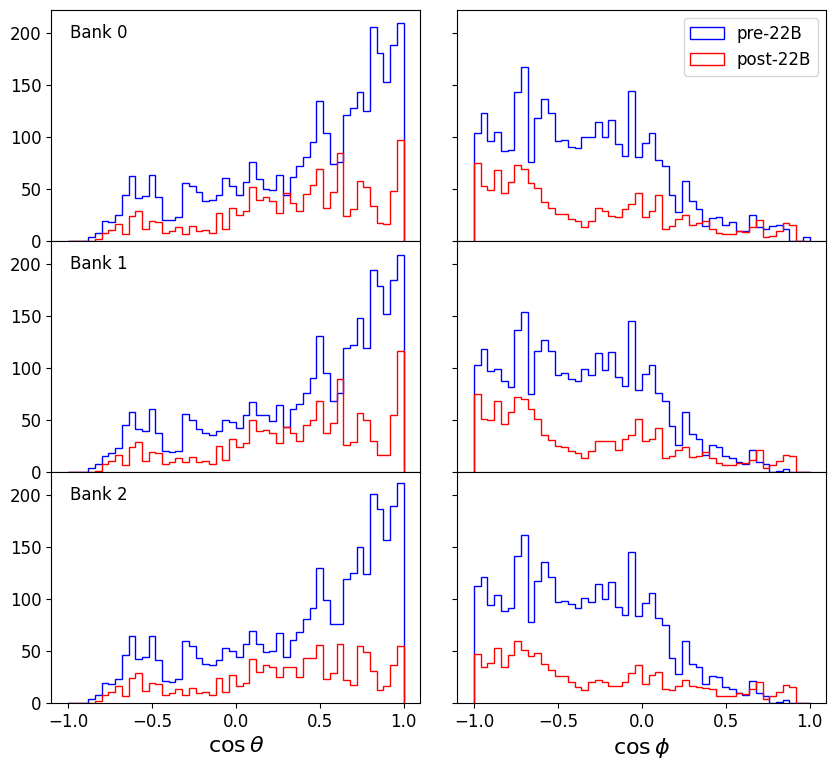

In [8]:
fig, axs = plt.subplots(3, 2, figsize=(10,9), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0, wspace=0.1)

for bank in range(3):
    data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/{bank}'
    files = [file[:-4] for file in os.listdir(data_dir)]
    info_bank = info[info['source'].isin(files)]

    info_pre22B = info_bank[info_bank['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9)]
    thetas_pre22B = [math.cos(math.radians(theta)) for theta in info_pre22B['theta']]
    phis_pre22B = [math.cos(math.radians(phi)) for phi in info_pre22B['phi']]

    info_post22B = info_bank[info_bank['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9)]
    thetas_post22B = [math.cos(math.radians(theta)) for theta in info_post22B['theta']]
    phis_post22B = [math.cos(math.radians(phi)) for phi in info_post22B['phi']]

    axs[bank][0].hist(thetas_pre22B, histtype='step', bins=np.linspace(-1, 1, 51), color='b', label='pre-22B')
    axs[bank][0].hist(thetas_post22B, histtype='step', bins=np.linspace(-1, 1, 51), color='r', label='post-22B')
    axs[bank][0].text(0.05, 0.9, f'Bank {bank}', transform=axs[bank][0].transAxes, ha='left', va='center')

    axs[bank][1].hist(phis_pre22B, histtype='step', bins=np.linspace(-1, 1, 51), color='b', label='pre-22B')
    axs[bank][1].hist(phis_post22B, histtype='step', bins=np.linspace(-1, 1, 51), color='r', label='post-22B')

axs[0][1].legend(loc='upper right')
axs[2][0].set_xlabel(r'$\cos{\theta}$', fontsize=16)
axs[2][1].set_xlabel(r'$\cos{\phi}$', fontsize=16)

# **II. The 8.4 GHz Doublet**

In [9]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/0/normalized_uninjected'

def get_intensity(name):
    candidate_freq = 8469 #MHz
    xs, ys = np.load(os.path.join(data_dir, name + '.npy'))
    freq_diff = xs[1] - xs[0]
    width = int(20 / freq_diff)
    idx = np.argmin(np.abs(xs - candidate_freq))
    return max(ys[idx-width:idx+width])

files = [file[:-4] for file in os.listdir(data_dir)]
info_bank_0 = info[info['source'].isin(files)]

colors = np.array(list(map(get_intensity, info_bank_0['source'])))
colors

array([1.000476  , 1.00041161, 1.00039278, ..., 1.0003915 , 1.00039212,
       1.00039383])

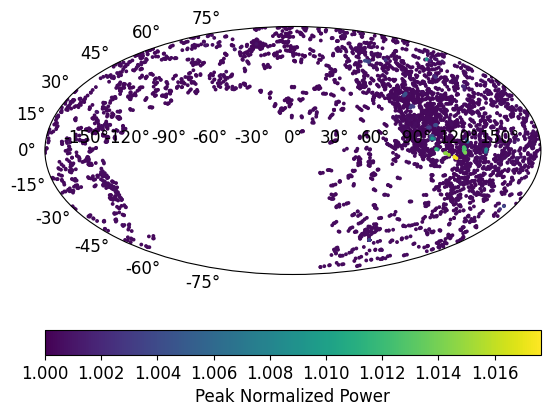

In [10]:
gal = SkyCoord(info_bank_0['l'], info_bank_0['b'], unit='deg', frame='galactic')
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')

sort_indices = np.argsort(colors)
ls = gal.l.wrap_at('180d').radian[sort_indices]
bs = gal.b.radian[sort_indices]
cs = colors[sort_indices]

scatter = plt.scatter(ls, bs, c=cs, s=3, vmin=1, vmax=max(colors), zorder=1)
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal')
cbar.set_label('Peak Normalized Power')

(5204800000.0, 5205800000.0)

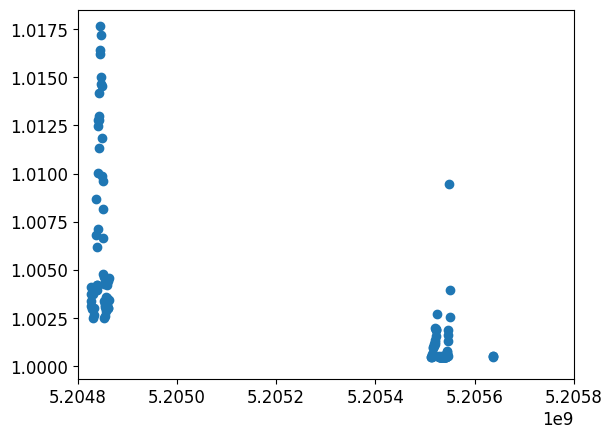

In [11]:
%matplotlib inline
times = info_bank_0['time'].apply(convert_to_seconds).to_numpy()
fig, ax = plt.subplots()
ax.scatter(times, colors)
ax.set_xlim(5.2048e9, 5.2058e9)

In [12]:
times_mask = (times > 5.2048e9) & (times < 5.2049e9)
times_trimmed = times[times_mask]
max(times_trimmed) - min(times_trimmed)

37072

(5205500000.0, 5205600000.0)

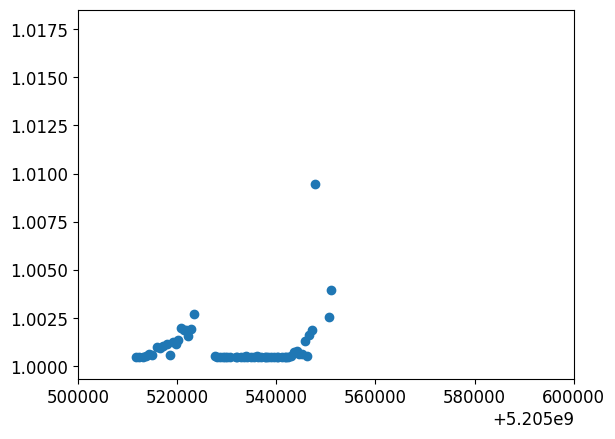

In [13]:
fig, ax = plt.subplots()
ax.scatter(times, colors)
ax.set_xlim(5.2055e9, 5.2056e9)

In [14]:
times_mask_2 = (times > 5.2055e9) & (times < 5.2056e9)
times_trimmed_2 = times[times_mask_2]
max(times_trimmed_2) - min(times_trimmed_2)

39303

## Normalized spectra 3D plots

In [15]:
freqs, _ = np.load(os.path.join(data_dir, os.listdir(data_dir)[0]))
freq_diff = freqs[1] - freqs[0]
mask = (freqs > 8450) & (freqs < 8500)
freqs_trimmed = freqs[mask]
time_indices = np.argsort(times)
xx, yy = np.meshgrid(freqs_trimmed, np.arange(len(times)), indexing='xy')
xx, yy

(array([[8450.04415512, 8450.22726059, 8450.41036606, ..., 8499.48263168,
         8499.66573715, 8499.84884262],
        [8450.04415512, 8450.22726059, 8450.41036606, ..., 8499.48263168,
         8499.66573715, 8499.84884262],
        [8450.04415512, 8450.22726059, 8450.41036606, ..., 8499.48263168,
         8499.66573715, 8499.84884262],
        ...,
        [8450.04415512, 8450.22726059, 8450.41036606, ..., 8499.48263168,
         8499.66573715, 8499.84884262],
        [8450.04415512, 8450.22726059, 8450.41036606, ..., 8499.48263168,
         8499.66573715, 8499.84884262],
        [8450.04415512, 8450.22726059, 8450.41036606, ..., 8499.48263168,
         8499.66573715, 8499.84884262]]),
 array([[   0,    0,    0, ...,    0,    0,    0],
        [   1,    1,    1, ...,    1,    1,    1],
        [   2,    2,    2, ...,    2,    2,    2],
        ...,
        [4772, 4772, 4772, ..., 4772, 4772, 4772],
        [4773, 4773, 4773, ..., 4773, 4773, 4773],
        [4774, 4774, 4774, ..., 4

In [16]:
zz = np.array([np.load(os.path.join(data_dir, name + '.npy'))[1][mask] for name in info_bank_0['source']])[time_indices]
zz

array([[0.99948323, 0.99948752, 0.99949315, ..., 1.00026805, 1.00025108,
        1.00023326],
       [0.99948354, 0.99948777, 0.9994934 , ..., 1.00026421, 1.00024716,
        1.00022939],
       [0.99948561, 0.99948982, 0.99949527, ..., 1.00026493, 1.00024795,
        1.00023032],
       ...,
       [0.99964219, 0.9996571 , 0.99967279, ..., 0.99979749, 0.99979938,
        0.9998012 ],
       [0.99965481, 0.99966996, 0.99968616, ..., 0.99980508, 0.99980682,
        0.99980846],
       [0.99965443, 0.99967053, 0.99968705, ..., 0.99980184, 0.9998038 ,
        0.99980599]])

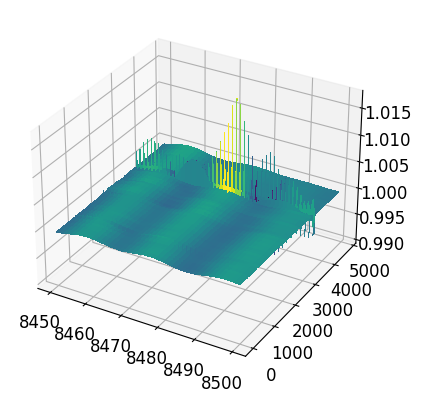

In [17]:
fig, ax = plt.subplots(subplot_kw={'projection':'3d'})
surf = ax.plot_surface(xx, yy, zz, cmap=cm.viridis, linewidth=0, antialiased=False)


### Raw spectra

In [18]:
times_trimmed_indices = np.argsort(times_trimmed)
xx, yy = np.meshgrid(freqs_trimmed, times_trimmed[times_trimmed_indices], indexing='xy')
xx, yy

(array([[8450.04415512, 8450.22726059, 8450.41036606, ..., 8499.48263168,
         8499.66573715, 8499.84884262],
        [8450.04415512, 8450.22726059, 8450.41036606, ..., 8499.48263168,
         8499.66573715, 8499.84884262],
        [8450.04415512, 8450.22726059, 8450.41036606, ..., 8499.48263168,
         8499.66573715, 8499.84884262],
        ...,
        [8450.04415512, 8450.22726059, 8450.41036606, ..., 8499.48263168,
         8499.66573715, 8499.84884262],
        [8450.04415512, 8450.22726059, 8450.41036606, ..., 8499.48263168,
         8499.66573715, 8499.84884262],
        [8450.04415512, 8450.22726059, 8450.41036606, ..., 8499.48263168,
         8499.66573715, 8499.84884262]]),
 array([[5204825638, 5204825638, 5204825638, ..., 5204825638, 5204825638,
         5204825638],
        [5204825963, 5204825963, 5204825963, ..., 5204825963, 5204825963,
         5204825963],
        [5204826603, 5204826603, 5204826603, ..., 5204826603, 5204826603,
         5204826603],
        ...,


In [19]:
files = info_bank_0[times_mask]['source'].to_numpy()[times_trimmed_indices]
raw_data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/0'
raw_freqs = np.load(os.path.join(raw_data_dir, os.listdir(raw_data_dir)[0]))[0]
raw_mask = (raw_freqs > 8450) & (raw_freqs < 8500)
zz = np.array([np.load(os.path.join(raw_data_dir, name + '.npy'))[1][raw_mask] for name in files])#[times_trimmed_indices]

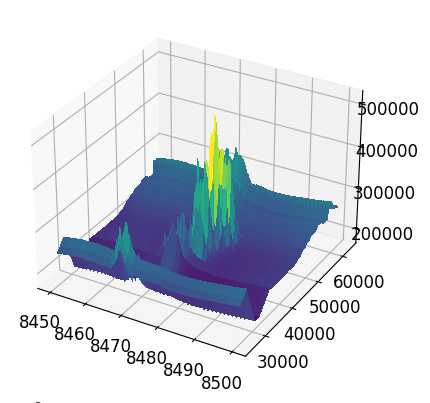

In [20]:
fig, ax = plt.subplots(subplot_kw={'projection':'3d'})
surf = ax.plot_surface(xx, yy, zz, cmap=cm.viridis, linewidth=0, antialiased=False)

In [21]:
len(zz)

58

# **III. Theta/Phi Over Time**

Text(0, 0.5, 'Time (s since MJD 0)')

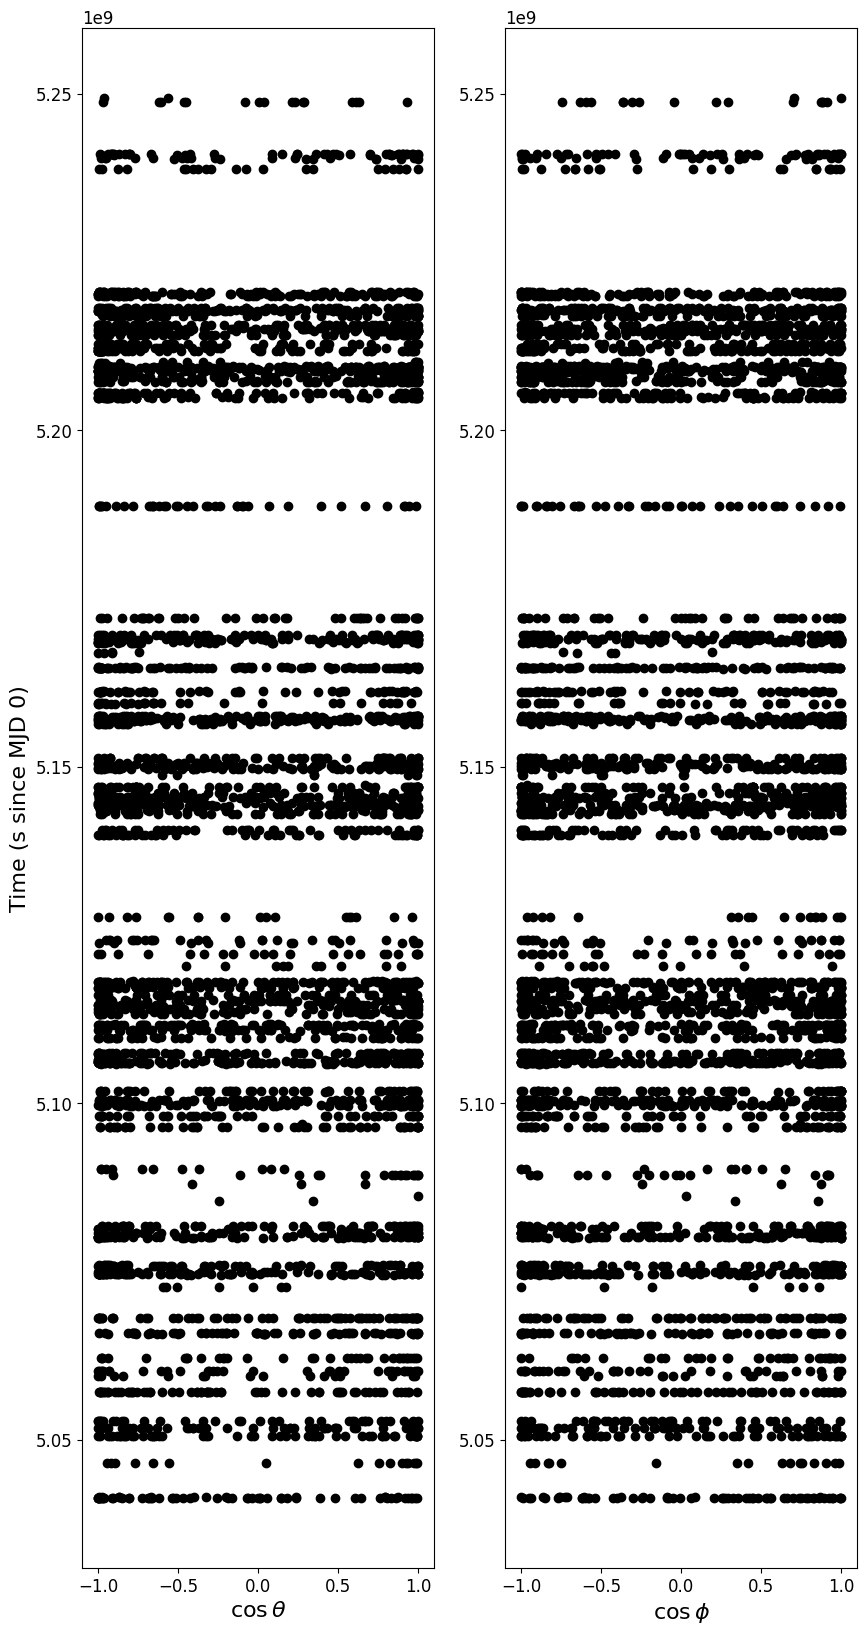

In [22]:
time_indices = np.argsort(info['time'].apply(convert_to_seconds).to_numpy())
times = info['time'].apply(convert_to_seconds).to_numpy()[time_indices]
thetas = info['theta'].apply(math.cos).to_numpy()[time_indices]
phis = info['phi'].apply(math.cos).to_numpy()[time_indices]

fig, axs = plt.subplots(1, 2, figsize=(10,20))
axs[0].scatter(thetas, times, c='k')
axs[0].set_xlabel(r'$\cos{\theta}$', fontsize=16)
axs[0].set_ylabel('Time (s since MJD 0)', fontsize=16)
axs[1].scatter(phis, times, c='k')
axs[1].set_xlabel(r'$\cos{\phi}$', fontsize=16)
axs[0].set_ylabel('Time (s since MJD 0)', fontsize=16)

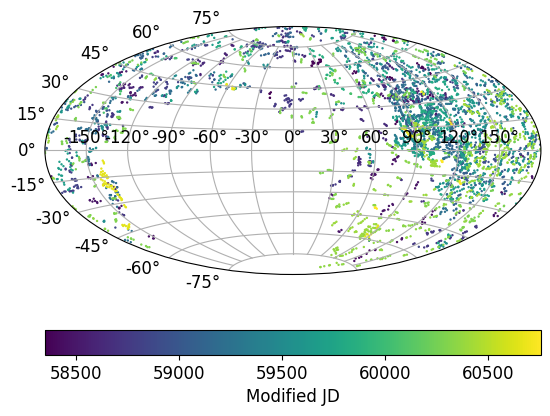

In [23]:
ls = info['l'].to_numpy()[time_indices]
bs = info['b'].to_numpy()[time_indices]
gal = SkyCoord(ls, bs, unit='deg', frame='galactic')
days = info['time'].apply(get_mjd)[time_indices]

fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)
scatter = plt.scatter(gal.l.wrap_at('180d').radian, gal.b.radian, c=days, s=0.5, zorder=1)
#cax = fig.add_axes([0.1, 0.1, 0.8, 0.03])
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal')
cbar.set_label('Modified JD')

# **IV. Generic Plotting Functions**

In [24]:
def plot_3D(bank, freq_lims=None, time_lims=None, time_index=True, norm=False):
    if norm:
        data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/{bank}/normalized_uninjected'
    else:
        data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/{bank}'
    
    files = [file[:-4] for file in os.listdir(data_dir)]
    info_temp = info[info['source'].isin(files)]

    freqs = np.load(os.path.join(data_dir, os.listdir(data_dir)[0]))[0]
    if freq_lims is None:
        freq_lims = (freqs[0], freqs[-1])
    freqs_mask = (freqs >= freq_lims[0]) & (freqs <= freq_lims[1])
    freqs_trimmed = freqs[freqs_mask]

    times = info_temp['time'].apply(convert_to_seconds).to_numpy()
    if time_lims is None:
        time_lims = (times[0], times[-1])
    times_mask = (times >= time_lims[0]) & (times <= time_lims[1])
    times_trimmed = times[times_mask]
    time_indices = np.argsort(times_trimmed)
    times_trimmed = times_trimmed[time_indices]

    if time_index:
        y = range(len(times_trimmed))
    else:
        y = times_trimmed
    
    xx, yy = np.meshgrid(freqs_trimmed, y)

    names = info_temp[times_mask]['source'].to_numpy()[time_indices]
    zz = np.array([np.load(os.path.join(data_dir, name + '.npy'))[1][freqs_mask] for name in names])
    
    fig, ax = plt.subplots(subplot_kw={'projection':'3d'})
    surf = ax.plot_surface(xx, yy, zz, cmap=cm.viridis, linewidth=0, antialiased=False)

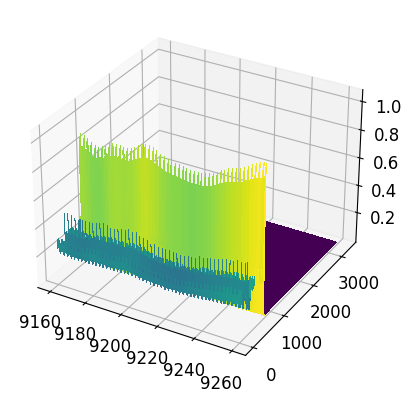

In [25]:
plot_3D(1, freq_lims=(9160, 9260), time_lims=(0, 5.18e9))

In [26]:
def plot_stacked(bank, freq_lims=None, time_lims=None, norm=False):
    if norm:
        data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/{bank}/normalized_uninjected'
    else:
        data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/{bank}'
    
    files = [file[:-4] for file in os.listdir(data_dir)]
    info_temp = info[info['source'].isin(files)]

    freqs = np.load(os.path.join(data_dir, os.listdir(data_dir)[0]))[0]
    if freq_lims is None:
        freq_lims = (freqs[0], freqs[-1])
    freqs_mask = (freqs >= freq_lims[0]) & (freqs <= freq_lims[1])

    times = info_temp['time'].apply(convert_to_seconds).to_numpy()
    if time_lims is None:
        time_lims = (np.sort(times)[0], np.sort(times)[-1])
    times_mask = (times >= time_lims[0]) & (times <= time_lims[1])
    times_trimmed = times[times_mask]
    time_indices = np.argsort(times_trimmed)
    times_trimmed = times_trimmed[time_indices]
    
    names = info_temp[times_mask]['source'].to_numpy()[time_indices]
    specs = np.array([np.load(os.path.join(data_dir, name + '.npy')) for name in names])
    
    fig, ax = plt.subplots()
    cmap = mpl.colormaps['viridis']
    norm_ = mpl.colors.Normalize(vmin=min(times_trimmed), vmax=max(times_trimmed))
    for i in range(len(specs)):
        x, y = (specs[i][0][freqs_mask], specs[i][1][freqs_mask] / np.median(specs[i][1][freqs_mask]))
        ax.plot(x, y, alpha=0.1, color=cmap(norm_(times_trimmed[i])))
    ax.set_xlabel(r'$\nu$ [MHz]')
    ylabel = 'Normalized Power' if norm else 'Power'
    ax.set_ylabel(ylabel)
    plt.colorbar(mpl.cm.ScalarMappable(norm=norm_, cmap=cmap), ax=ax, label='Time (s since MJD 0)')
    

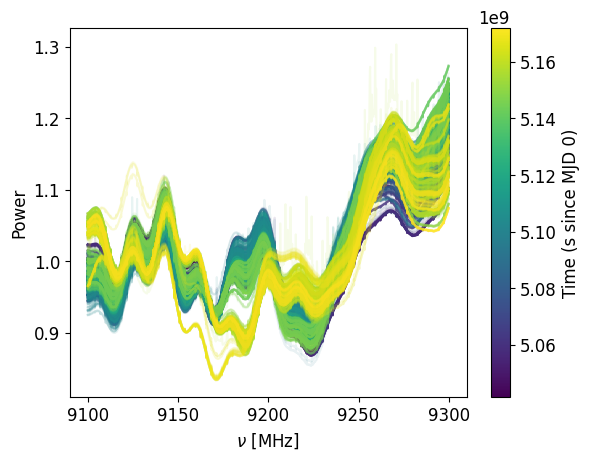

In [27]:
plot_stacked(1, freq_lims=(9100, 9300), time_lims=(0, 5.18e9))

Not helpful... maybe a heatmap?

In [28]:
def raw_heatmap(bank, freq_lims=None, time_lims=None, n_bins=50):
    data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/{bank}'
    
    if time_lims is None:
        time_lims = (times[0], times[-1])
    files = [file[:-4] for file in os.listdir(data_dir)]
    cond1 = info['source'].isin(files)
    cond2 = info['time'].apply(lambda t: (convert_to_seconds(t) >= time_lims[0]) and (convert_to_seconds(t) <= time_lims[1]))
    info_temp = info[cond1 & cond2]

    info_temp['time_mjd'] = [int(mjd.split('_')[0]) for mjd in info_temp['time']]
    time_bins = np.linspace(min(info_temp['time_mjd']), max(info_temp['time_mjd']), n_bins+1)
    info_temp['time_mjd_bin'] = pd.cut(info_temp['time_mjd'], time_bins, labels=False)

    freqs = np.load(os.path.join(data_dir, os.listdir(data_dir)[0]))[0]
    if freq_lims is None:
        freq_lims = (freqs[0], freqs[-1])
    mask = (freqs >= freq_lims[0]) & (freqs < freq_lims[1])
    nans = np.full(freqs.shape, np.nan)[mask]

    def load_spectrum(file):
        spec = np.load(os.path.join(data_dir, file))[1][mask]
        return spec / np.median(spec)

    def create_map(bin_column):
        for i in range(n_bins):
            sources = info_temp[info_temp[bin_column] == i]['source'].tolist()
            spectra = np.array([load_spectrum(file) for file in os.listdir(data_dir) if file[:-4] in sources])
            if spectra.size:
                avg = np.mean(spectra, axis=0)
                yield avg
            else:
                yield nans

    time_map = list(create_map('time_mjd_bin'))

    fig, ax = plt.subplots(figsize=(12,6))

    extent = [np.min(freqs[mask]), np.max(freqs[mask]), min(info_temp['time_mjd']), max(info_temp['time_mjd'])]

    im = ax.imshow(time_map, extent=extent, origin='lower', aspect='auto')
    
    ax.set_ylabel('Modified JD', fontsize=18)
    ax.set_xlabel(r'$\nu$ [MHz]', fontsize=18)

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.0335, pad=0.04)
    cbar.set_label('Power', fontsize=18)

/tmp/ipykernel_4176630/1691021464.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info_temp['time_mjd'] = [int(mjd.split('_')[0]) for mjd in info_temp['time']]
/tmp/ipykernel_4176630/1691021464.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info_temp['time_mjd_bin'] = pd.cut(info_temp['time_mjd'], time_bins, labels=False)


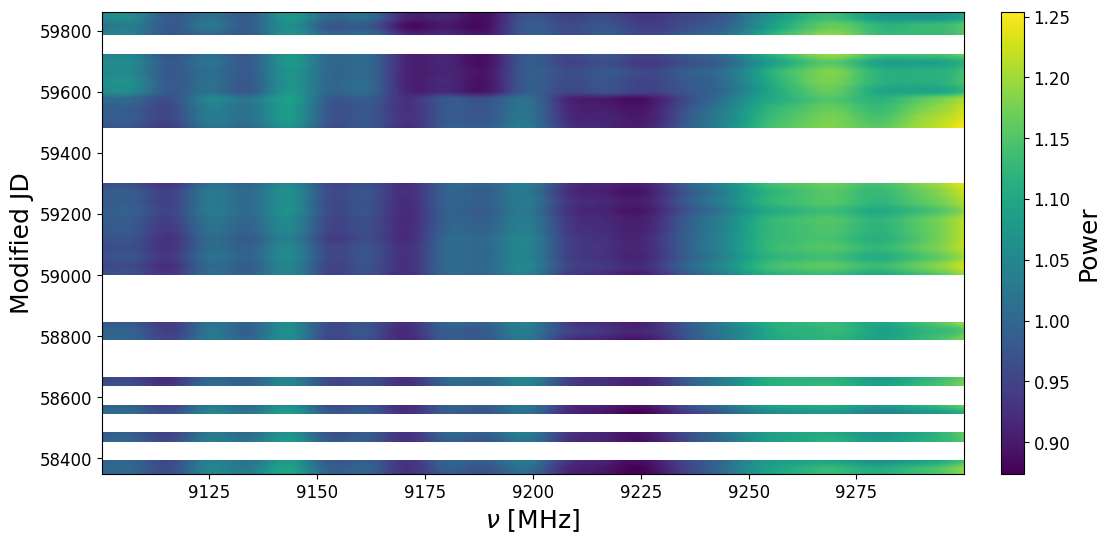

In [29]:
raw_heatmap(1, freq_lims=(9100, 9300), time_lims=(0, 5.18e9))

# **V. Heatmap for an Injection at the Sensitivity Limit**

In [30]:
def heatmap(data_dir, freq_lims=None, time_lims=None, n_bins=50):    
    if time_lims is None:
        time_lims = (times[0], times[-1])
    files = [file[:-4] for file in os.listdir(data_dir)]
    cond1 = info['source'].isin(files)
    cond2 = info['time'].apply(lambda t: (convert_to_seconds(t) >= time_lims[0]) and (convert_to_seconds(t) <= time_lims[1]))
    info_temp = info[cond1 & cond2]

    info_temp['cos_theta'] = [math.cos(math.radians(theta)) for theta in info_temp['theta']]
    info_temp['cos_phi'] = [math.cos(math.radians(phi)) for phi in info_temp['phi']]
    
    bins = np.linspace(-1, 1, n_bins+1)
    info_temp['cos_theta_bin'] = pd.cut(info_temp['cos_theta'], bins, labels=False)
    info_temp['cos_phi_bin'] = pd.cut(info_temp['cos_phi'], bins, labels=False)

    freqs = np.load(os.path.join(data_dir, os.listdir(data_dir)[0]))[0]
    if freq_lims is None:
        freq_lims = (freqs[0], freqs[-1])
    mask = (freqs >= freq_lims[0]) & (freqs < freq_lims[1])
    nans = np.full(freqs.shape, np.nan)[mask]

    def create_map(bin_column):
        for i in range(n_bins):
            sources = info_temp[info_temp[bin_column] == i]['source'].tolist()
            spectra = np.array([np.load(os.path.join(data_dir, file))[1][mask] for file in os.listdir(data_dir) if file[:-4] in sources])
            if spectra.size:
                avg = np.mean(spectra, axis=0)
                yield avg
            else:
                yield nans

    theta_map = list(create_map('cos_theta_bin'))
    phi_map = list(create_map('cos_phi_bin'))

    fig, axs = plt.subplots(2, 1, figsize=(12,6))
    plt.subplots_adjust(hspace=0.15)

    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(np.array(theta_map))
    vmax = max(vmax, 2 - vmin)
    ndigits = -int(math.floor(math.log10(vmax - 1))) + 1
    vmax = round(vmax, ndigits)
    vmin = 2 - vmax
    norm = Normalize(vmin=vmin, vmax=vmax)
    extent = [np.min(freqs[mask]), np.max(freqs[mask]), -1, 1]

    im0 = axs[0].imshow(theta_map, extent=extent, origin='lower', norm=norm, aspect='auto')
    im1 = axs[1].imshow(phi_map, extent=extent, origin='lower', norm=norm, aspect='auto')
    
    axs[0].set_ylabel(r'$\mathrm{cos}({\theta})$', fontsize=18)
    axs[1].set_ylabel(r'$\mathrm{cos}({\phi})$', fontsize=18)
    axs[1].set_xlabel(r'$\nu$ [MHz]', fontsize=18)
    
    for ax in axs:
        ax.set_yticks([-1,0,1])

    axs[0].set_xticklabels([])
    cbar = fig.colorbar(im0, ax=axs.ravel().tolist(), orientation='vertical', fraction=0.0335, pad=0.04, ticks=np.linspace(vmin, vmax, 5))
    cbar.set_label('Normalized Power', fontsize=18)

/tmp/ipykernel_4176630/4215279938.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info_temp['cos_theta'] = [math.cos(math.radians(theta)) for theta in info_temp['theta']]
/tmp/ipykernel_4176630/4215279938.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info_temp['cos_phi'] = [math.cos(math.radians(phi)) for phi in info_temp['phi']]
/tmp/ipykernel_4176630/4215279938.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

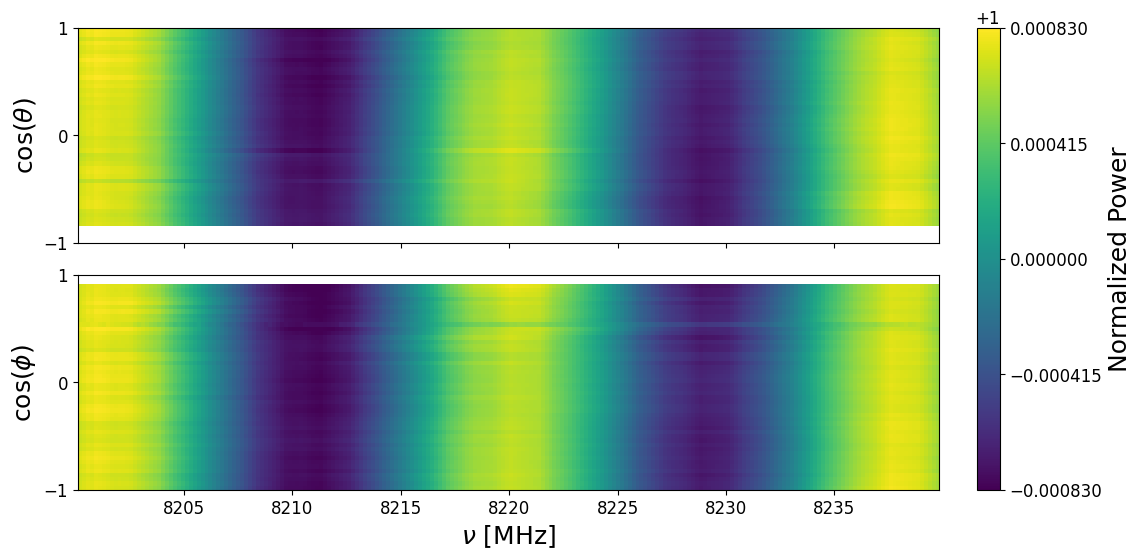

In [63]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/0/start_7820/iter_0/normalized_injected'
heatmap(data_dir, freq_lims=(8200, 8240), time_lims=(5.18e9, 1e10))

/tmp/ipykernel_4176630/4215279938.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info_temp['cos_theta'] = [math.cos(math.radians(theta)) for theta in info_temp['theta']]
/tmp/ipykernel_4176630/4215279938.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info_temp['cos_phi'] = [math.cos(math.radians(phi)) for phi in info_temp['phi']]
/tmp/ipykernel_4176630/4215279938.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

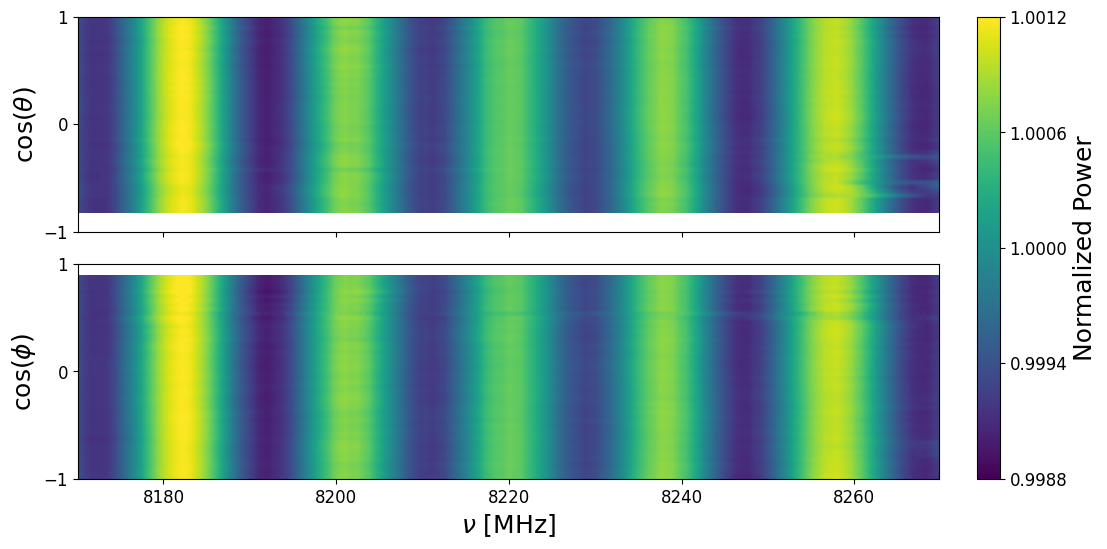

In [32]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/0/normalized_uninjected'
heatmap(data_dir, freq_lims=(8170, 8270), time_lims=(5.18e9, 1e10))

# **VI. Inspecting the Remaining Candidates**

## 8120 MHz

In [33]:
def aitoff(bank, freq):
    data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/{bank}/normalized_uninjected'
    
    def get_intensity(name):
        xs, ys = np.load(os.path.join(data_dir, name + '.npy'))
        freq_diff = xs[1] - xs[0]
        width = int(20 / freq_diff)
        idx = np.argmin(np.abs(xs - freq))
        return max(ys[idx-width:idx+width])

    files = [file[:-4] for file in os.listdir(data_dir)]
    info_temp = info[info['source'].isin(files)]

    colors = np.array(list(map(get_intensity, info_temp['source'])))
    
    gal = SkyCoord(info_temp['l'], info_temp['b'], unit='deg', frame='galactic')
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='aitoff')

    sort_indices = np.argsort(colors)
    ls = gal.l.wrap_at('180d').radian[sort_indices]
    bs = gal.b.radian[sort_indices]
    cs = colors[sort_indices]

    scatter = plt.scatter(ls, bs, c=cs, s=3, vmin=1, vmax=max(colors), zorder=1)
    cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal')
    cbar.set_label('Peak Normalized Power')

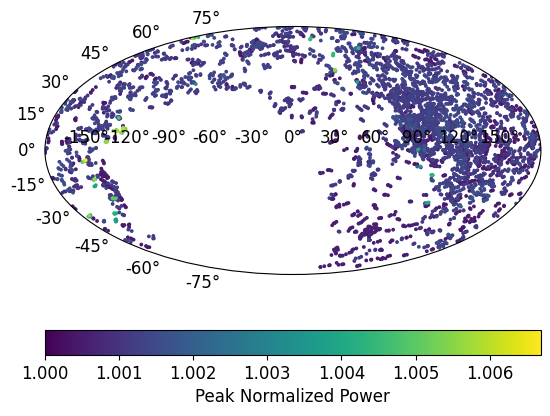

In [34]:
aitoff(0, 8120)

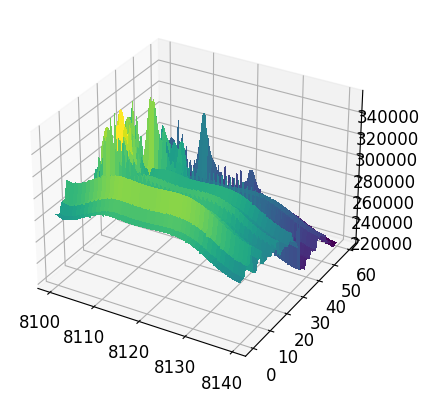

In [35]:
plot_3D(0, freq_lims=(8100, 8140), time_lims=(5.2093e9, 5.2094e9))

In [36]:
def get_intensity(name, freq, data_dir):
    xs, ys = np.load(os.path.join(data_dir, name + '.npy'))
    freq_diff = xs[1] - xs[0]
    width = int(20 / freq_diff)
    idx = np.argmin(np.abs(xs - freq))
    return max(ys[idx-width:idx+width])

def plot_peaks(bank, freq, time_lims=None):
    data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/{bank}/normalized_uninjected'

    files = [file[:-4] for file in os.listdir(data_dir)]
    info_temp = info[info['source'].isin(files)]

    get_intensity_partial = partial(get_intensity, freq=freq, data_dir=data_dir)
    colors = np.array(list(map(get_intensity_partial, info_temp['source'])))

    times = info_temp['time'].apply(convert_to_seconds).to_numpy()
    
    fig, ax = plt.subplots()
    ax.scatter(times, colors)
    ax.set_xlim(time_lims)

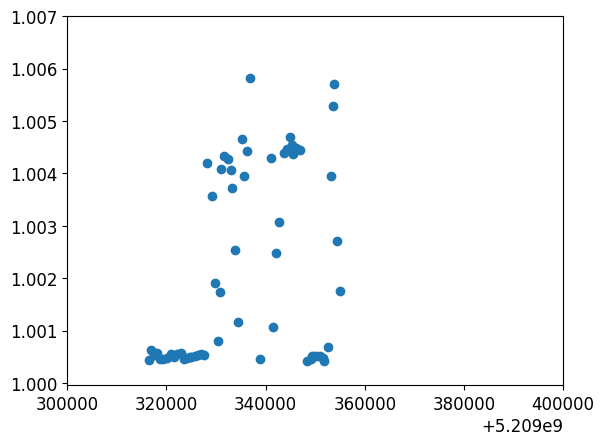

In [37]:
plot_peaks(0, 8120, (5.2093e9, 5.2094e9))

## 8301 MHz

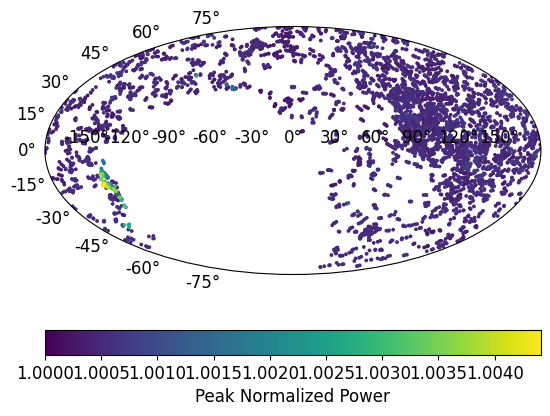

In [38]:
aitoff(0, 8301)

## 8991 MHz

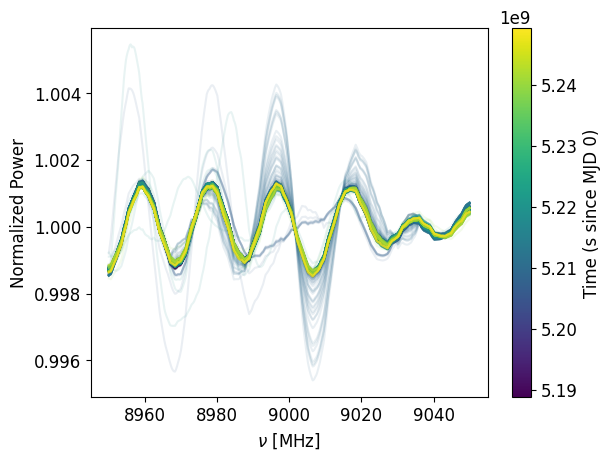

In [39]:
plot_stacked(1, freq_lims=(8950, 9050), time_lims=(5.18e9, 1e10), norm=True)

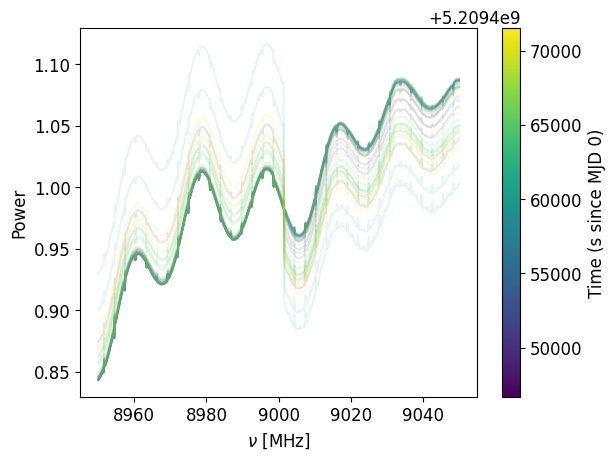

In [40]:
plot_stacked(1, freq_lims=(8950, 9050), time_lims=(5.2094e9, 5.2095e9))

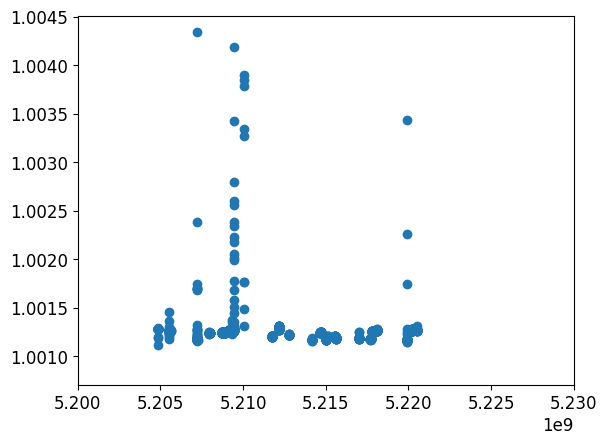

In [41]:
plot_peaks(1, 8991, (5.2e9, 5.23e9))

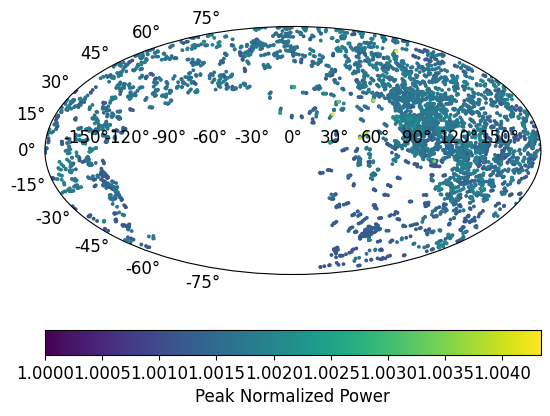

In [42]:
aitoff(1,8991)

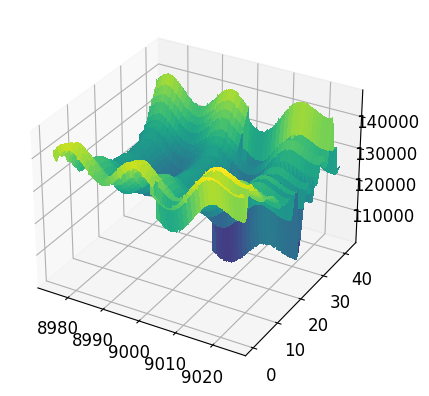

In [43]:
plot_3D(1, freq_lims=(8975, 9025), time_lims=(5.2094e9, 5.2095e9))

(array([2., 4., 1., 3., 0., 0., 2., 2., 3., 7.]),
 array([-0.96629296, -0.76980193, -0.5733109 , -0.37681986, -0.18032883,
         0.0161622 ,  0.21265323,  0.40914426,  0.60563529,  0.80212632,
         0.99861736]),
 <BarContainer object of 10 artists>)

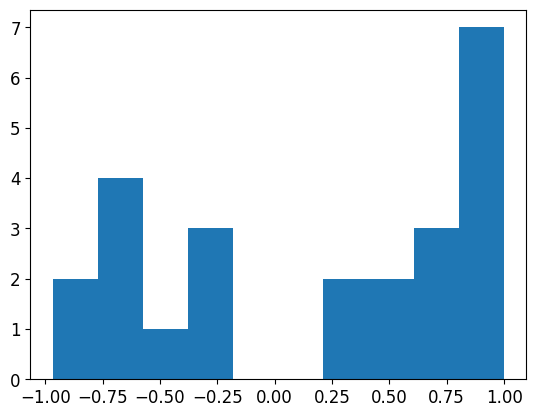

In [44]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/1/normalized_uninjected'
files = [file[:-4] for file in os.listdir(data_dir)]
info_bank_1 = info[info['source'].isin(files)]
info_bank_1_trimmed = info_bank_1[info_bank_1['time'].apply(lambda t: (convert_to_seconds(t) > 5.2e9) and (convert_to_seconds(t) < 5.21e9))]
info_bank_1_trimmed = info_bank_1_trimmed[info_bank_1_trimmed['source'].apply(lambda l: get_intensity(l, 8991, data_dir) > 1.0015)]
plt.hist(info_bank_1_trimmed['phi'].apply(math.cos))

In [45]:
info_bank_1_trimmed['source']

898     HIP89986
899     HIP74689
909     HIP79695
911     HIP77052
913     HIP76779
917     HIP74761
924     HIP79465
927     HIP84521
932     HIP81461
935     HIP89944
970     HIP84363
982     HIP77165
984     HIP76886
993     HIP82452
995     HIP82476
1011    HIP74304
1813    HIP58001
1816    HIP57487
1817    HIP57483
1818    HIP57558
1819    HIP63894
1820    HIP63398
1821    HIP64088
1824    HIP64805
Name: source, dtype: object

(8900.0, 9100.0)

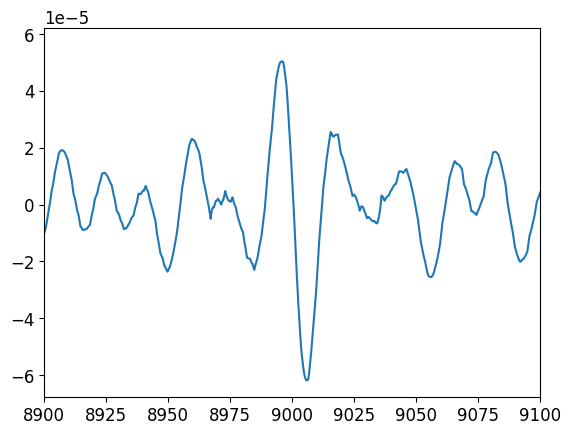

In [46]:
plt.plot(*np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/1/uninj_int_asymmetry.npy'))
plt.xlim(8900, 9100)

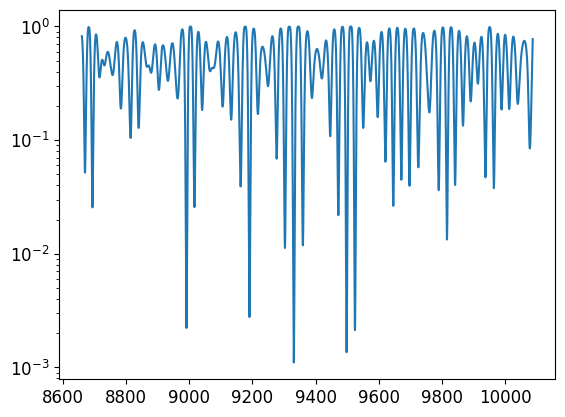

In [47]:
plt.plot(*np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/1/uninj_int_pvals.npy'))
plt.yscale('log')

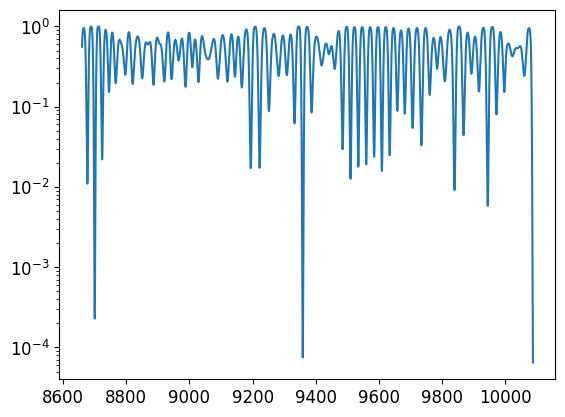

In [48]:
plt.plot(*np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/1/uninj_dopp_pvals.npy'))
plt.yscale('log')

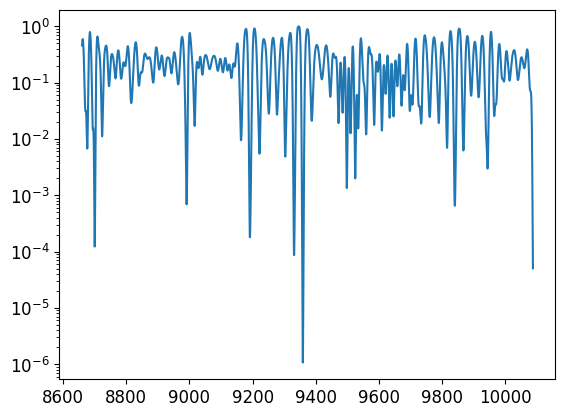

In [49]:
plt.plot(*np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/1/uninj_combined_pvals.npy'))
plt.yscale('log')

## 10464 MHz

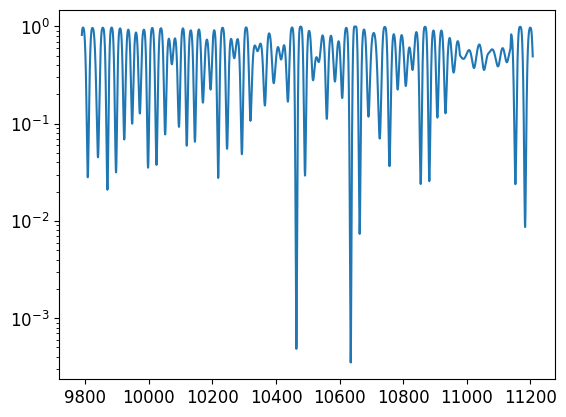

In [50]:
plt.plot(*np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/2/uninj_dopp_pvals.npy'))
plt.yscale('log')

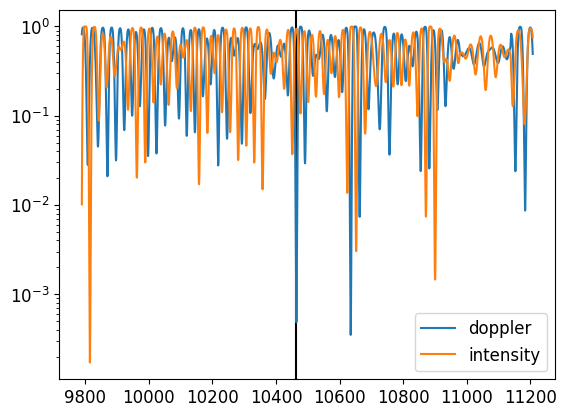

In [51]:
plt.axvline(10464, c='k')
plt.plot(*np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/2/uninj_dopp_pvals.npy'), label='doppler')
plt.plot(*np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/2/uninj_int_pvals.npy'), label='intensity')
plt.legend()
plt.yscale('log')

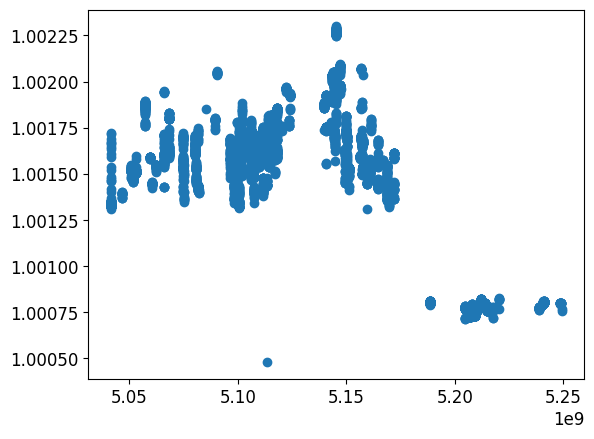

In [52]:
plot_peaks(2, 10464)

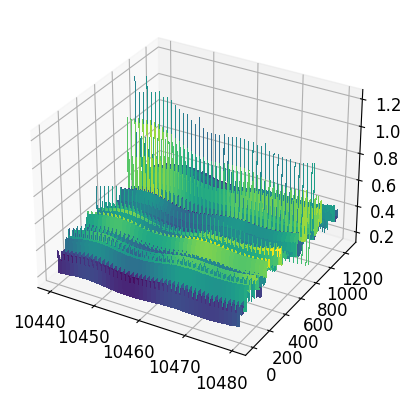

In [53]:
plot_3D(2, freq_lims=(10440, 10480), time_lims=(5.14e9, 5.17e9))

/tmp/ipykernel_4176630/1691021464.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info_temp['time_mjd'] = [int(mjd.split('_')[0]) for mjd in info_temp['time']]
/tmp/ipykernel_4176630/1691021464.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info_temp['time_mjd_bin'] = pd.cut(info_temp['time_mjd'], time_bins, labels=False)


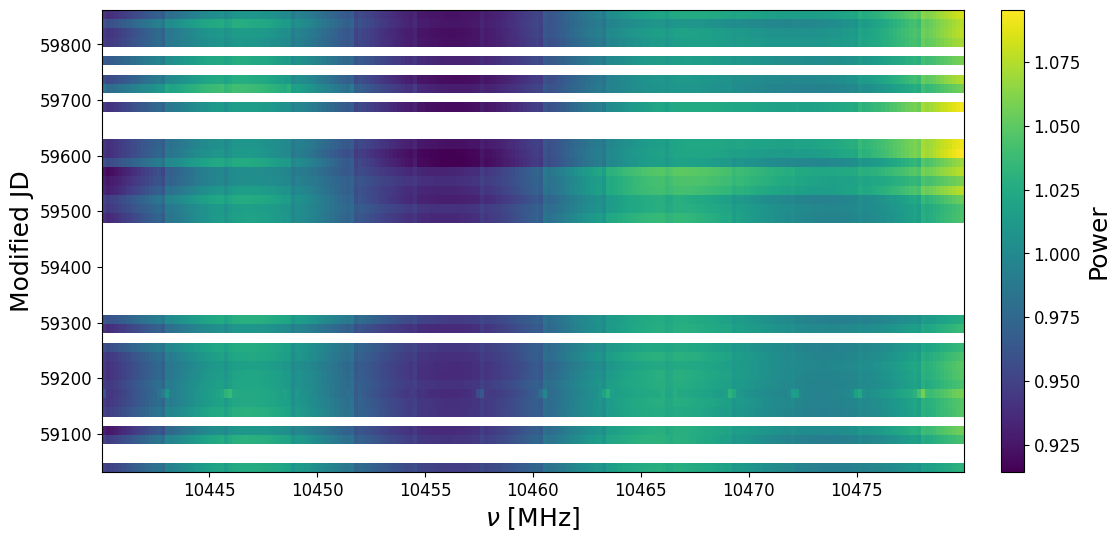

In [54]:
raw_heatmap(2, (10440, 10480), (5.10e9, 5.18e9))

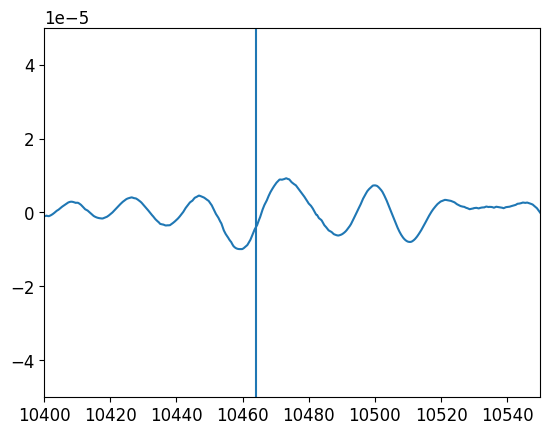

In [55]:
plt.plot(*np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/2/uninj_dopp_asymmetry.npy'))
plt.xlim(10400, 10550)
plt.ylim(-5e-5, 5e-5)
plt.axvline(10464)

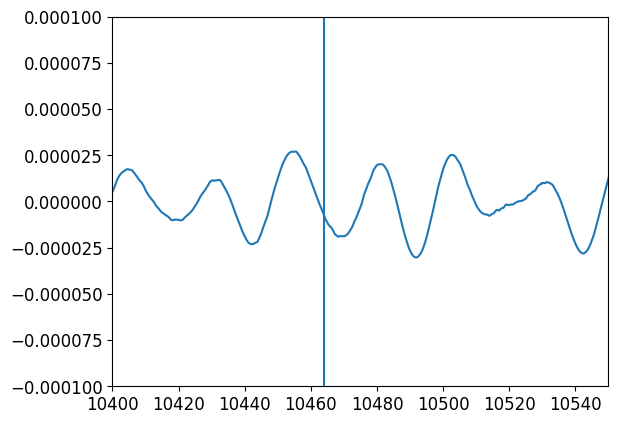

In [56]:
plt.plot(*np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/2/uninj_int_asymmetry.npy'))
plt.xlim(10400, 10550)
plt.ylim(-1e-4, 1e-4)
plt.axvline(10464)

Yeah, this intensity asymmetry is not convincing...

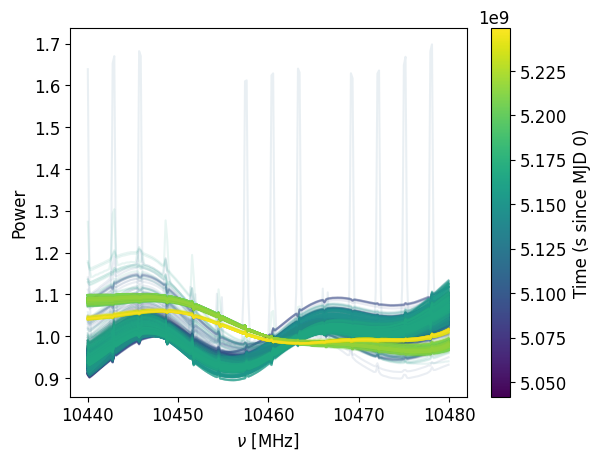

In [57]:
plot_stacked(2, freq_lims=(10440, 10480))

## Plotting 10464 with pre-2022 spectra - asymmetries, p-vals.

### P-value code stuff

In [34]:
from scipy.interpolate import interp1d

def build_asymmetry_modified(spectra, names, angle, lower, upper):
    
    inner_pre = info[(info[angle] < lower) & (info['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9))]
    inner_post = info[(info[angle] < lower) & (info['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9))]
    outer_pre = info[(info[angle] > upper) & (info['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9))]
    outer_post = info[(info[angle] > upper) & (info['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9))]

    inner_pre_spectra = [file[1] for file, name in zip(spectra, names) if name in inner_pre['source'].tolist()]
    inner_post_spectra = [file[1] for file, name in zip(spectra, names) if name in inner_post['source'].tolist()]
    outer_pre_spectra = [file[1] for file, name in zip(spectra, names) if name in outer_pre['source'].tolist()]
    outer_post_spectra = [file[1] for file, name in zip(spectra, names) if name in outer_post['source'].tolist()]

    inner_pre_mean = np.mean(inner_pre_spectra, axis=0)
    inner_post_mean = np.mean(inner_post_spectra, axis=0)
    outer_pre_mean = np.mean(outer_pre_spectra, axis=0)
    outer_post_mean = np.mean(outer_post_spectra, axis=0)

    asymmetry = (inner_pre_mean + inner_post_mean - outer_pre_mean - outer_post_mean) / (inner_pre_mean + inner_post_mean + outer_pre_mean + outer_post_mean)
    xs = spectra[0][0]
    asymmetry = sigma_filter(asymmetry)
    return xs, asymmetry


def correlate_asymmetry(freqs, spectrum, template):
    def stretch_template(template, stretch_factor):
        if template.shape[0] % 2 == 0:
            template = template[1:] # Make the number of points odd
        k = template.shape[0] // 2
        orig_x = np.arange(-k, k+1)
        interp_func = interp1d(orig_x, template, bounds_error=False, fill_value=0)
        new_k = ((2*k + 1)/stretch_factor - 1)/2 # 2k_1 + 1 = sf*(2k_0 + 1)
        new_x = np.linspace(-new_k, new_k, template.shape[0])

        return interp_func(new_x)

    def get_a(target, template):
        return np.dot(target, template) / (np.dot(template, template) + 1e-12)
    
    a_vals = np.zeros_like(spectrum)
    residuals = np.zeros_like(spectrum)
    lower = (len(template) - 1) // 2
    upper = (len(template) + 1) // 2
    for i in range(len(spectrum)):
        stretched = stretch_template(template, freqs[i] / 8500)
        
        if i < lower:
            x = lower - i
            stretched = stretched[x:]
            window = spectrum[:i+upper]
        elif i > (len(spectrum) - upper):
            x = len(spectrum) - upper - i
            stretched = stretched[:x]
            window = spectrum[i-lower:]
        else:
            window = spectrum[i-lower:i+upper]
        
        a = get_a(window, stretched) 
        a_vals[i] = a 
        residuals[i] = np.sqrt(np.mean((a*stretched-window)**2)) 

    return a_vals / (residuals + 1e-12)


def calc_pvals(uninj, window_size=400):
    window_half_size = window_size // 2
    stds = []
    for i in range(len(uninj)):
        if i < window_half_size:
            slice = uninj[:i+window_half_size]
        elif i >= len(uninj) - window_half_size:
            slice = uninj[i-window_half_size:]
        else:
            slice = uninj[i-window_half_size:i+window_half_size]
        stds.append(np.std(slice))

    sigmas = uninj / stds
    pvals = list(map(lambda sigma: .5*math.erfc(sigma/np.sqrt(2)), sigmas))
    return pvals
  
    
def sigma_filter(data, window_size=15):
    for i in range(window_size//2, len(data)-window_size//2):
        window_data = data[i-window_size//2:i+window_size//2+1]
        median = np.median(window_data)
        std = np.std(window_data)
        if abs(data[i] - median) > 3 * std:
            data[i] = median
    return data

In [35]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/2'

names = info[info['epoch'].apply(lambda l: int(l.split('_')[0][4:-1]) >= 22)]['source']
names = names[names.apply(lambda l: l + '.npy').isin(os.listdir(data_dir))]
names

0       HIP62637
17      HIP60910
18      HIP75767
19      HIP53697
20      HIP62860
          ...   
4745    HIP74916
4746    HIP78403
4749    HIP72530
4751    HIP72409
4756    HIP75431
Name: source, Length: 1819, dtype: object

In [36]:
os.chdir('/home/bhanselman/bhanselman/scripts')
from normalization_methods import *

In [37]:
from tqdm import tqdm
from multiprocessing import Pool

In [38]:
def normalize(name):
    return normalize_weighted(
        name+'.npy',
        data_dir=data_dir,
        exterior=8,
        freq=10464,
        width=100
    )

with Pool(processes=10) as p:
    normalized = list(tqdm(p.imap_unordered(normalize, names), total=len(names)))

100%|██████████| 1819/1819 [03:13<00:00,  9.41it/s]


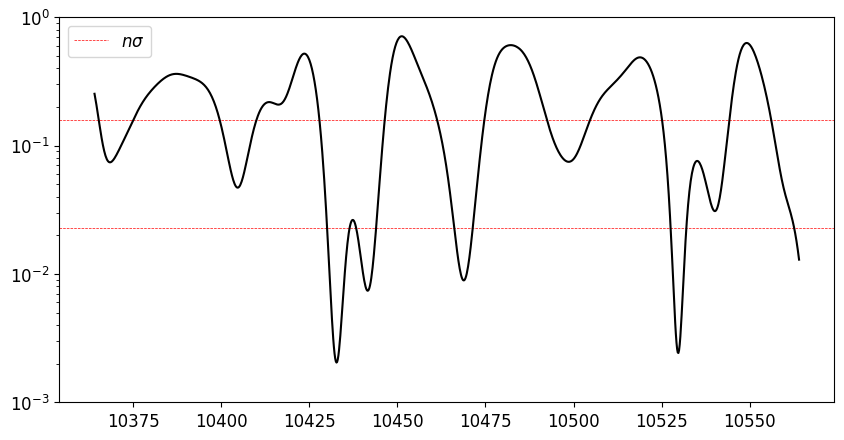

In [39]:
xs, doppler = build_asymmetry_modified(normalized, names, 'theta', 65, 65)
xs, intensity = build_asymmetry_modified(normalized, names, 'phi', 70, 115)

temp_dopp = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/doppler_template.npy')[1]
temp_int = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/intensity_template.npy')[1]

corr_dopp = correlate_asymmetry(xs, doppler, temp_dopp)
corr_int = correlate_asymmetry(xs, intensity, temp_int)

combined_pvals = np.multiply(calc_pvals(corr_dopp, window_size=800), calc_pvals(corr_int, window_size=800))

fig, ax = plt.subplots(figsize=(10,5))
i = 0
while .5*math.erfc((i+1)/np.sqrt(2)) > min(combined_pvals):
    label = '$n\sigma$' if not i else None
    ax.axhline(.5*math.erfc((i+1)/np.sqrt(2)), c='red', ls='--', lw=0.5, label=label)
    i += 1
ax.plot(xs, combined_pvals, c='k')
ax.set_yscale('log')
ax.set_ylim(10 ** (math.floor(np.log10(min(combined_pvals)))), 1)
ax.legend()

# **VII. Miscellaneous**

## i. Original vs. Modified Asymmetry Comparison, All Banks

In [7]:
def sigma_filter(data, window_size=15):
    for i in range(window_size//2, len(data)-window_size//2):
        window_data = data[i-window_size//2:i+window_size//2+1]
        median = np.median(window_data)
        std = np.std(window_data)
        if abs(data[i] - median) > 3 * std:
            data[i] = median
    return data

def build_asymmetry(data_dir, angle, lower, upper, spectra=None):
    if spectra is None:
        spectra = os.listdir(data_dir)
    inner = info[info[angle] < lower]
    outer = info[info[angle] > upper]
    inner_spectra = np.array([np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner['source'].tolist()])
    outer_spectra = np.array([np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer['source'].tolist()])    
    inner_mean = np.mean(inner_spectra, axis=0)
    outer_mean = np.mean(outer_spectra, axis=0)
    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean)
    xs = np.load(os.path.join(data_dir, spectra[0]))[0]
    asymmetry = sigma_filter(asymmetry)
    return xs, asymmetry

def build_asymmetry_modified(data_dir, angle, lower, upper, spectra=None):
    if spectra is None:
        spectra = os.listdir(data_dir)
    
    inner_pre = info[(info[angle] < lower) & (info['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9))]
    inner_post = info[(info[angle] < lower) & (info['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9))]
    outer_pre = info[(info[angle] > upper) & (info['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9))]
    outer_post = info[(info[angle] > upper) & (info['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9))]

    inner_pre_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner_pre['source'].tolist()]
    inner_post_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner_post['source'].tolist()]
    outer_pre_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer_pre['source'].tolist()]
    outer_post_spectra = [np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer_post['source'].tolist()]

    inner_pre_mean = np.mean(inner_pre_spectra, axis=0)
    inner_post_mean = np.mean(inner_post_spectra, axis=0)
    outer_pre_mean = np.mean(outer_pre_spectra, axis=0)
    outer_post_mean = np.mean(outer_post_spectra, axis=0)

    asymmetry = (inner_pre_mean + inner_post_mean - outer_pre_mean - outer_post_mean) / (inner_pre_mean + inner_post_mean + outer_pre_mean + outer_post_mean)
    xs = np.load(os.path.join(data_dir, spectra[0]))[0]
    asymmetry = sigma_filter(asymmetry)
    return xs, asymmetry

0 doppler 5.5769441068548934e-05 2.8379922556520524e-05 1.9651019468950397
0 intensity 5.3001594862889514e-05 4.0950998041623466e-05 1.294268696675416
1 doppler 2.316269160247307e-05 5.859179597123734e-06 3.953231202170969
1 intensity 5.9764126989498275e-05 1.5724051236969854e-05 3.8008097333709325
2 doppler 0.00018710131008552945 1.9164342567717206e-05 9.762991317046591
2 intensity 0.0003979623787891264 2.3795463468703576e-05 16.724296179922575


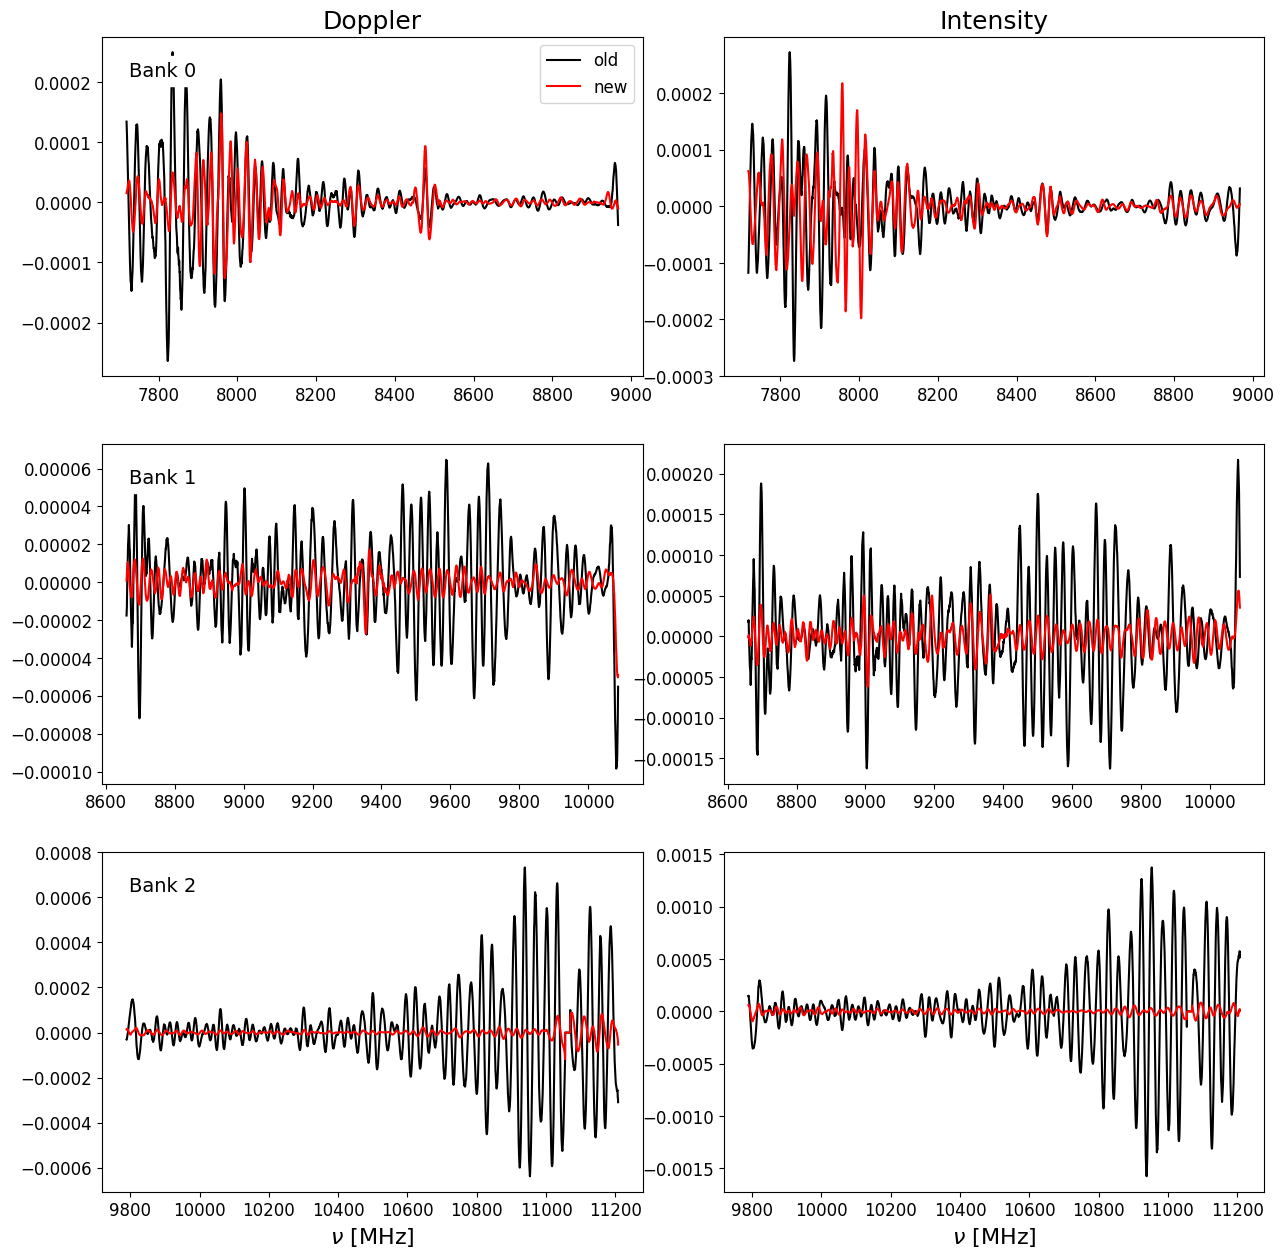

In [59]:
fig, axs = plt.subplots(3, 2, figsize=(15,15))
plt.subplots_adjust(wspace=0.15)
for bank in range(3):
    data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/{bank}/normalized_uninjected'
    for i, mode in enumerate(['doppler', 'intensity']):
        args = ('theta', 65, 65) if mode == 'doppler' else ('phi', 70, 115)
        
        xs, asymmetry_old = build_asymmetry(data_dir, *args)
        xs, asymmetry_new = build_asymmetry_modified(data_dir, *args)

        # Eh I'm lazy
        if bank == 2:
            start = np.argmin(np.abs(xs - 11055))
            stop = np.argmin(np.abs(xs - 11070))
            asymmetry_old[start:stop] = 0
            asymmetry_new[start:stop] = 0

        std_old = np.std(asymmetry_old)
        std_new = np.std(asymmetry_new)
        factor = std_old / std_new

        axs[bank][i].plot(xs, asymmetry_old, color='k', label='old')
        axs[bank][i].plot(xs, asymmetry_new, color='r', label='new')
        print(bank, mode, std_old, std_new, factor)
    
    t = axs[bank][0].text(0.05, 0.9, f'Bank {bank}', transform=axs[bank][0].transAxes, ha='left', va='center', fontsize=14)
    t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
    
axs[0][0].legend()
axs[0][0].set_title('Doppler', fontsize=18)
axs[0][1].set_title('Intensity', fontsize=18)

for i in range(2):
    axs[2][i].set_xlabel(r'$\nu$ [MHz]', fontsize=16)

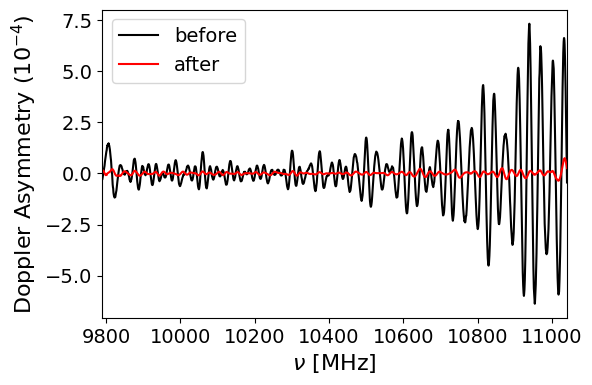

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
plt.subplots_adjust(hspace=0.1)
plt.rcParams.update({'font.size': 14})

bank = 2
data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/analysis_20251130/decay/{bank}/normalized_uninjected'
args = ('theta', 65, 65)

xs, asymmetry_old = build_asymmetry(data_dir, *args)
xs, asymmetry_new = build_asymmetry_modified(data_dir, *args)

start = np.argmin(np.abs(xs - 11055))
stop = np.argmin(np.abs(xs - 11070))
asymmetry_old[start:stop] = 0
asymmetry_new[start:stop] = 0

asymmetry_old = asymmetry_old * 1e4
asymmetry_new = asymmetry_new * 1e4

std_old = np.std(asymmetry_old)
std_new = np.std(asymmetry_new)
factor = std_old / std_new

ax.plot(xs, asymmetry_old, color='k', label='before')
ax.plot(xs, asymmetry_new, color='r', label='after')

ax.legend()
ax.set_xlim(xs[0], 11040)

ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
ax.set_ylabel(r'Doppler Asymmetry ($10^{-4}$)', fontsize=16)

plt.savefig('/home/dataadmin/GBTData/SharedDataDirectory/asymmetries_goldwater.png', dpi=300, bbox_inches='tight')


## ii. Mean vs. Median SEFDs

In [61]:
targets = ['3C123', '3C147', '3C196', '3C286', '3C295', '3C48']
calibration_path = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/'
med_sefd_path = '/home/dataadmin/GBTData/SharedDataDirectory/median_sefds/'

def get_mean(row):
    q1 = np.percentile(row, 25)
    q3 = np.percentile(row, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    row[(row < lower_bound) | (row > upper_bound)] = np.nan
    mean = np.nanmean(row)
    return mean

def get_std(row):
    q1 = np.percentile(row, 25)
    q3 = np.percentile(row, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    row[(row < lower_bound) | (row > upper_bound)] = np.nan
    std = np.nanstd(row)
    return std

for bank in range(3):
    pre2023 = []
    post2023 = []
    shape = 7168 if bank == 0 else 8192
    for target in targets:
        calibration_dir = os.path.join(calibration_path, str(bank), target)
        if not os.path.exists(calibration_dir):
            print(f'No data for {target} in bank {bank}, skipping')
            continue
        for cadence in os.listdir(calibration_dir):
            path = os.path.join(calibration_dir, cadence, 'SEFD.npy')
            try:
                sefd = np.load(path)
                if sefd.shape[1] != shape:
                    print(f'SEFD shape mismatch for {bank}/{target}/{cadence}, skipping')
                    print(sefd.shape)
                    continue
                time = convert_to_seconds(cadence)
                if time < 5.18e9:
                    pre2023.append(sefd)
                else:
                    post2023.append(sefd)
            except FileNotFoundError:
                print(f'SEFD.npy not found for {bank}/{target}/{cadence}, skipping')
                continue
    if pre2023:
        freqs = pre2023[0][0]
        specs = np.array([spectrum[1] for spectrum in pre2023])
        specs_transposed = specs.T
        pre2023_mean = list(map(get_mean, specs_transposed))
        pre2023_std = list(map(get_std, specs_transposed))
        pre2023_mean = np.array([freqs, pre2023_mean])
        pre2023_std = np.array([freqs, pre2023_std])

        np.save(os.path.join(med_sefd_path, str(bank), 'pre2023_mean.npy'), pre2023_mean)
        np.save(os.path.join(med_sefd_path, str(bank), 'pre2023_std.npy'), pre2023_std)
        
    if post2023:
        freqs = post2023[0][0]
        specs = np.array([spectrum[1] for spectrum in post2023])
        specs_transposed = specs.T
        post2023_mean = list(map(get_mean, specs_transposed))
        post2023_std = list(map(get_std, specs_transposed))
        post2023_mean = np.array([freqs, post2023_mean])
        post2023_std = np.array([freqs, post2023_std])

        np.save(os.path.join(med_sefd_path, str(bank), 'post2023_mean.npy'), post2023_mean)
        np.save(os.path.join(med_sefd_path, str(bank), 'post2023_std.npy'), post2023_std)

SEFD shape mismatch for 0/3C196/59525_56816, skipping
(2, 6144)
SEFD shape mismatch for 0/3C295/59348_41294, skipping
(2, 4096)


SEFD shape mismatch for 1/3C48/59572_22577, skipping
(2, 7168)


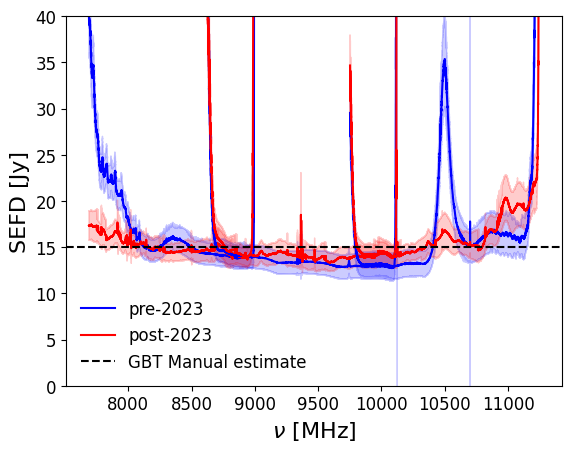

In [62]:
# Plot the median SEFDs
plt.rcParams.update({'font.size': 12})

for bank in range(3):
    path = os.path.join(med_sefd_path, str(bank))
    if os.path.exists(path):
        pre2023_mean = np.load(os.path.join(path, 'pre2023_mean.npy'))
        pre2023_std = np.load(os.path.join(path, 'pre2023_std.npy'))
        plt.plot(pre2023_mean[0], pre2023_mean[1], color='blue', label='pre-2023' if bank == 0 else None)
        plt.fill_between(pre2023_mean[0], pre2023_mean[1] - pre2023_std[1], pre2023_mean[1] + pre2023_std[1], color='blue', alpha=0.2)
        post2023_mean = np.load(os.path.join(path, 'post2023_mean.npy'))
        post2023_std = np.load(os.path.join(path, 'post2023_std.npy'))
        plt.plot(post2023_mean[0], post2023_mean[1], color='red', label='post-2023' if bank == 0 else None)
        plt.fill_between(post2023_mean[0], post2023_mean[1] - post2023_std[1], post2023_mean[1] + post2023_std[1], color='red', alpha=0.2)

plt.ylim(0,40)
plt.axhline(15, color='k', linestyle='--', label='GBT Manual estimate')
plt.legend(frameon=False)
plt.xlabel('$\\nu$ [MHz]', fontsize=16)
plt.ylabel('SEFD [Jy]', fontsize=16)
plt.savefig('/home/dataadmin/GBTData/SharedDataDirectory/mean_sefds_aas.png', dpi=300, bbox_inches='tight')